In [1]:
# ==============================
#modelA_visual_model_training
# ==============================

import os
import pandas as pd
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import torch
import torchvision.transforms as transforms

# ======================
# CONFIG
# ======================
CSV_PATH = "train_metadata.csv"  # your generated metadata file
BATCH_SIZE = 32
IMG_SIZE = 224
NUM_WORKERS = 4  # increase if GPU + CPU are strong

# ======================
# 1. LOAD CSV
# ======================
# (Your CSV uses commas, not tabs)
df = pd.read_csv(CSV_PATH)

# Clean up bad rows
df = df.dropna(subset=["path", "label"])
df["path"] = df["path"].astype(str).str.strip()
df["label"] = df["label"].astype(str).str.strip()

# Filter out empty labels and non-integer values
df = df[df["label"].isin(["0", "1"])]
df["label"] = df["label"].astype(int)

print(f"✅ Cleaned dataset: {len(df)} samples")
print(df.head())

✅ Cleaned dataset: 544876 samples
                                                path  label
0  preprocessed_asvspoof\FaceForensics++\original...      0
1  preprocessed_asvspoof\FaceForensics++\original...      0
2  preprocessed_asvspoof\FaceForensics++\original...      0
3  preprocessed_asvspoof\FaceForensics++\original...      0
4  preprocessed_asvspoof\FaceForensics++\original...      0


In [2]:


# ======================
# 2. SPLIT DATA
# ======================
train_df, test_df = train_test_split(
    df, test_size=0.1, stratify=df["label"], random_state=42
)
train_df, val_df = train_test_split(
    train_df, test_size=0.1, stratify=train_df["label"], random_state=42
)

print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")

# ======================
# 3. DEFINE DATASET CLASS
# ======================
class DeepfakeDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_path = self.df.loc[idx, "path"]
        label = int(self.df.loc[idx, "label"])

        # Handle missing or corrupted images gracefully
        try:
            image = Image.open(img_path).convert("RGB")
        except Exception as e:
            print(f"[WARN] Skipping broken file: {img_path}")
            # Return a blank image with label 0 (or skip in collate_fn)
            image = Image.new("RGB", (IMG_SIZE, IMG_SIZE), color=(0, 0, 0))

        if self.transform:
            image = self.transform(image)

        return image, torch.tensor(label, dtype=torch.long)

# ======================
# 4. TRANSFORMS
# ======================
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(5),
    transforms.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# ======================
# 5. DATALOADERS
# ======================
train_dataset = DeepfakeDataset(train_df, transform=train_transform)
val_dataset = DeepfakeDataset(val_df, transform=val_transform)
test_dataset = DeepfakeDataset(test_df, transform=val_transform)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=False
)
val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=False
)
test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=False
)

print("✅ Dataloaders ready!")
print(f"Total train batches: {len(train_loader)}")
print(f"Total val batches: {len(val_loader)}")
print(f"Total test batches: {len(test_loader)}")


Train: 441349 | Val: 49039 | Test: 54488
✅ Dataloaders ready!
Total train batches: 13793
Total val batches: 1533
Total test batches: 1703


In [4]:
# =======================
# BLOCK 1 — IMPORTS & SETUP
# =======================
import os
import time
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models
import timm
from torch.amp import GradScaler, autocast
from torch.utils.tensorboard import SummaryWriter
from tqdm import tqdm

print("✅ Block 1 completed: Imports & setup loaded successfully.")


✅ Block 1 completed: Imports & setup loaded successfully.


In [4]:
# =======================
# BLOCK 2 — CONFIG
# =======================
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
EPOCHS = 50
LR = 1e-4
NUM_CLASSES = 2
SAVE_DIR = "checkpoints"
LOG_DIR = "runs/training_" + time.strftime("%Y%m%d-%H%M%S")
SAVE_PERIOD_EPOCHS = 5
BEST_CKPT = os.path.join(SAVE_DIR, "best_model.pth")
LAST_CKPT = os.path.join(SAVE_DIR, "last_model.pth")

os.makedirs(SAVE_DIR, exist_ok=True)
os.makedirs(LOG_DIR, exist_ok=True)

print(f"Device: {DEVICE}")
print(f"Save dir: {SAVE_DIR}")
print(f"TensorBoard logs: {LOG_DIR}")
print("✅ Block 2 completed: Configuration set.")


Device: cuda
Save dir: checkpoints
TensorBoard logs: runs/training_20251013-153215
✅ Block 2 completed: Configuration set.


In [5]:
# =======================
# BLOCK 3 — MODEL DEFINITION
# =======================
class CNN_Transformer_Fusion(nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()
        # EfficientNet-B4 backbone
        self.cnn = models.efficientnet_b4(weights="IMAGENET1K_V1")
        self.cnn.classifier = nn.Identity()
        cnn_out = 1792

        # Vision Transformer (ViT)
        self.transformer = timm.create_model("vit_base_patch16_224", pretrained=True)
        self.transformer.head = nn.Identity()
        trans_out = 768

        # Fusion network
        self.fusion = nn.Sequential(
            nn.Linear(cnn_out + trans_out, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        cnn_feat = self.cnn(x)
        trans_feat = self.transformer(x)
        fused = torch.cat([cnn_feat, trans_feat], dim=1)
        return self.fusion(fused)

print("✅ Block 3 completed: Model defined successfully.")


✅ Block 3 completed: Model defined successfully.


In [6]:
# =======================
# BLOCK 4 — MODEL INIT
# =======================
model = CNN_Transformer_Fusion(num_classes=NUM_CLASSES).to(DEVICE)
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
scaler = GradScaler(device='cuda')
writer = SummaryWriter(LOG_DIR)

print("✅ Block 4 completed: Model, optimizer, scheduler, AMP, and logger initialized.")


NameError: name 'NUM_CLASSES' is not defined

In [7]:
# =======================
# BLOCK 5 — RESUME SUPPORT
# =======================
start_epoch = 0
best_val_acc = 0.0

if os.path.exists(BEST_CKPT):
    try:
        ckpt = torch.load(BEST_CKPT, map_location=DEVICE)
        model.load_state_dict(ckpt["model"])
        optimizer.load_state_dict(ckpt["optimizer"])
        scheduler.load_state_dict(ckpt.get("scheduler", scheduler.state_dict()))
        scaler.load_state_dict(ckpt.get("scaler", scaler.state_dict()))
        best_val_acc = ckpt.get("best_acc", 0.0)
        start_epoch = ckpt.get("epoch", 0) + 1
        print(f"Resumed best checkpoint from epoch {start_epoch-1} with acc {best_val_acc:.4f}")
    except Exception as e:
        print("⚠️ Could not resume best checkpoint:", e)

if os.path.exists(LAST_CKPT) and start_epoch == 0:
    try:
        ckpt = torch.load(LAST_CKPT, map_location=DEVICE)
        model.load_state_dict(ckpt["model"])
        optimizer.load_state_dict(ckpt["optimizer"])
        scheduler.load_state_dict(ckpt.get("scheduler", scheduler.state_dict()))
        scaler.load_state_dict(ckpt.get("scaler", scaler.state_dict()))
        start_epoch = ckpt.get("epoch", 0) + 1
        best_val_acc = ckpt.get("best_acc", best_val_acc)
        print(f"Resumed last checkpoint from epoch {start_epoch-1}")
    except Exception as e:
        print("⚠️ Could not resume last checkpoint:", e)

print("✅ Block 5 completed: Resume check done.")


✅ Block 5 completed: Resume check done.


In [11]:
# =======================
# BLOCK 6 — VALIDATION FUNCTION
# =======================
def evaluate(model, loader):
    model.eval()
    total, correct, loss_sum = 0, 0, 0.0
    with torch.no_grad():
        for imgs, labels in tqdm(loader, desc="Eval", leave=False):
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            with autocast(device_type=DEVICE):
                outputs = model(imgs)
                loss = criterion(outputs, labels)
            loss_sum += loss.item() * imgs.size(0)
            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    return loss_sum / max(1, total), correct / max(1, total)

print("✅ Block 6 completed: Evaluation function ready.")


✅ Block 6 completed: Evaluation function ready.


In [3]:
import time

print("Testing a single batch from train_loader...")
t0 = time.time()
for i, (imgs, labels) in enumerate(train_loader):
    print(f"✅ Got batch {i+1} | Shape: {imgs.shape} | Labels: {labels[:5]}")
    break
print(f"⏱️ Time taken for first batch: {time.time()-t0:.2f} sec")


Testing a single batch from train_loader...
✅ Got batch 1 | Shape: torch.Size([32, 3, 224, 224]) | Labels: tensor([1, 1, 1, 1, 1])
⏱️ Time taken for first batch: 0.26 sec


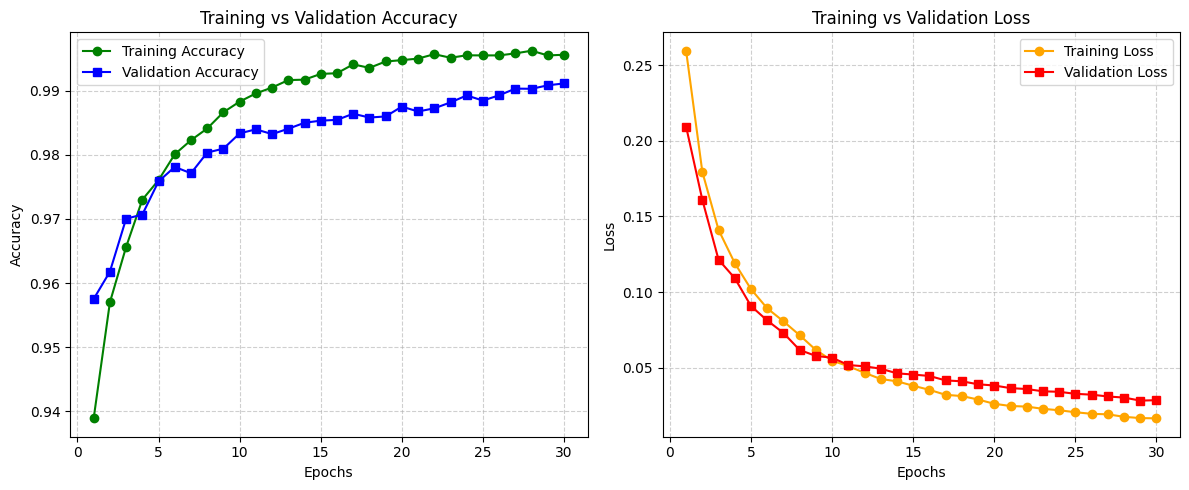

In [14]:
# =======================
# BLOCK 7 — TRAINING LOOP
# =======================
try:
    for epoch in range(start_epoch, EPOCHS):
        t0 = time.time()
        model.train()
        running_loss, running_correct, running_total = 0.0, 0, 0

        print(f"🚀 Starting Epoch {epoch+1}/{EPOCHS}")
        loop = tqdm(train_loader, desc=f"Train Epoch {epoch+1}", leave=False)
        for imgs, labels in loop:
            imgs, labels = imgs.to(DEVICE, non_blocking=True), labels.to(DEVICE, non_blocking=True)
            optimizer.zero_grad()
            with autocast(device_type=DEVICE):
                outputs = model(imgs)
                loss = criterion(outputs, labels)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            running_loss += loss.item() * imgs.size(0)
            preds = outputs.argmax(dim=1)
            running_correct += (preds == labels).sum().item()
            running_total += labels.size(0)

        train_loss = running_loss / running_total
        train_acc = running_correct / running_total

        val_loss, val_acc = evaluate(model, val_loader)
        scheduler.step()

        print(f"✅ Epoch {epoch+1} completed | Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f} | Time: {(time.time()-t0)/60:.2f} min")

        # Log metrics
        writer.add_scalar("Loss/train", train_loss, epoch+1)
        writer.add_scalar("Loss/val", val_loss, epoch+1)
        writer.add_scalar("Acc/train", train_acc, epoch+1)
        writer.add_scalar("Acc/val", val_acc, epoch+1)

        # Save checkpoints
        state = {
            "epoch": epoch,
            "model": model.state_dict(),
            "optimizer": optimizer.state_dict(),
            "scheduler": scheduler.state_dict(),
            "scaler": scaler.state_dict(),
            "best_acc": best_val_acc
        }
        torch.save(state, LAST_CKPT)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(state, BEST_CKPT)
            print(f"🔥 New best model saved at epoch {epoch+1} (Val Acc: {val_acc:.4f})")

        if (epoch + 1) % SAVE_PERIOD_EPOCHS == 0:
            periodic_path = os.path.join(SAVE_DIR, f"ckpt_epoch_{epoch+1}.pth")
            torch.save(state, periodic_path)
            print(f"💾 Periodic checkpoint saved: {periodic_path}")

    print("✅ Block 7 completed: Training finished successfully.")

except KeyboardInterrupt:
    print("\n⛔ Training interrupted. Saving checkpoint...")
    torch.save({
        "epoch": epoch,
        "model": model.state_dict(),
        "optimizer": optimizer.state_dict(),
        "scheduler": scheduler.state_dict(),
        "scaler": scaler.state_dict(),
        "best_acc": best_val_acc
    }, LAST_CKPT)
    print("✅ Last checkpoint saved before exit.")



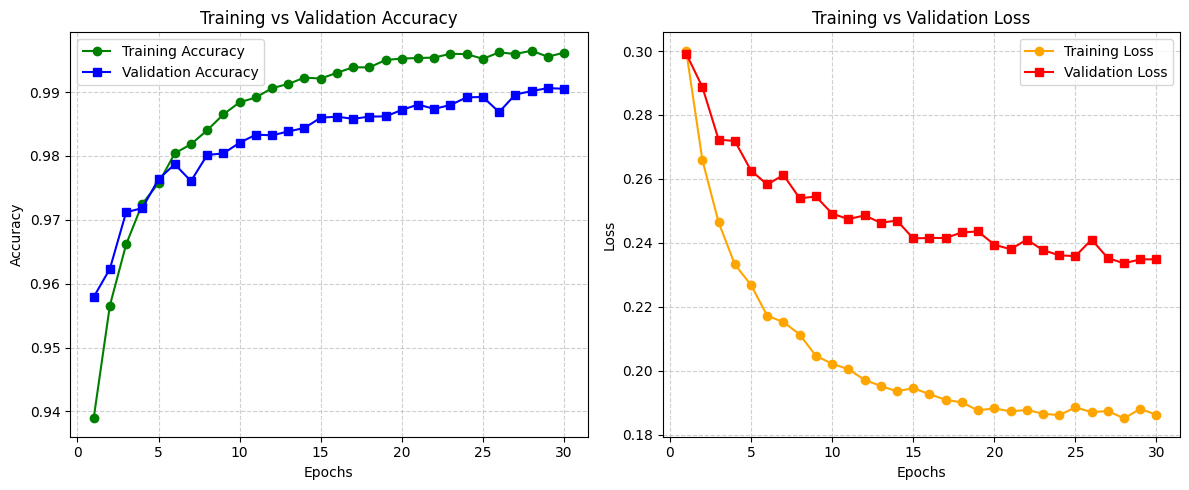

In [13]:
import torch
import torch.nn as nn
from torchvision import models
import timm
from torch.cuda.amp import autocast
from tqdm import tqdm

# same DEVICE as before
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# ======================
# 1️⃣ DEFINE MODEL
# ======================
class CNN_Transformer_Fusion(nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()
        self.cnn = models.efficientnet_b4(weights="IMAGENET1K_V1")
        self.cnn.classifier = nn.Identity()
        cnn_out = 1792

        self.transformer = timm.create_model("vit_base_patch16_224", pretrained=True)
        self.transformer.head = nn.Identity()
        trans_out = 768

        self.fusion = nn.Sequential(
            nn.Linear(cnn_out + trans_out, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.3),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        cnn_feat = self.cnn(x)
        trans_feat = self.transformer(x)
        fused = torch.cat([cnn_feat, trans_feat], dim=1)
        return self.fusion(fused)

# ======================
# 2️⃣ LOAD CHECKPOINT
# ======================
model = CNN_Transformer_Fusion(num_classes=2).to(DEVICE)
ckpt = torch.load("checkpoints/ckpt_epoch_10.pth", map_location=DEVICE)
model.load_state_dict(ckpt["model"])
model.eval()
print("✅ Loaded checkpoint from epoch 10")

# ======================
# 3️⃣ DEFINE EVALUATE FUNCTION
# ======================
criterion = nn.CrossEntropyLoss()

def evaluate(model, loader):
    model.eval()
    total, correct, loss_sum = 0, 0, 0.0
    with torch.no_grad():
        for imgs, labels in tqdm(loader, desc="Evaluating", leave=False):
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            with autocast():
                outputs = model(imgs)
                loss = criterion(outputs, labels)
            loss_sum += loss.item() * imgs.size(0)
            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    return loss_sum / max(1, total), correct / max(1, total)



In [4]:
import csv, torch, torch.nn.functional as F
model.eval()
rows = []
with torch.no_grad():
    for imgs, labels in tqdm(test_loader):
        imgs = imgs.to(DEVICE)
        outputs = model(imgs)
        probs = F.softmax(outputs, dim=1)[:,1].cpu().numpy()   # prob for class 1 (fake)
        preds = outputs.argmax(dim=1).cpu().numpy()
        labels = labels.numpy()
        # assume test_loader.dataset.df has corresponding paths in same order
        # get batch paths:
        start_idx = None
        # simpler: iterate dataset indices to match loader order:
# easier reliable way (single-threaded):
rows = []
for idx in range(len(test_loader.dataset)):
    img, label = test_loader.dataset[idx]
    path = test_loader.dataset.df.loc[idx, "path"]
    img = img.unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        out = model(img)
        prob = torch.nn.functional.softmax(out, dim=1)[0,1].item()
        pred = int(out.argmax(dim=1).item())
    rows.append((path, int(label.item()), pred, prob))

with open("predictions.csv","w",newline="") as f:
    w = csv.writer(f)
    w.writerow(["path","true_label","predicted_label","prob_fake"])
    w.writerows(rows)
print("Saved predictions.csv")


100%|██████████████████████████████████████████████████████████████████████████████| 1703/1703 [07:44<00:00,  3.67it/s]


Saved predictions.csv


In [7]:
import shutil, random
from pathlib import Path

out_dir = Path("examples_for_figures")
out_dir.mkdir(exist_ok=True)

# sample 4 real and 4 fake
real_paths = test_loader.dataset.df[test_loader.dataset.df["label"]==0].sample(4, random_state=42)["path"].tolist()
fake_paths = test_loader.dataset.df[test_loader.dataset.df["label"]==1].sample(4, random_state=42)["path"].tolist()
for p in real_paths + fake_paths:
    shutil.copy(p, out_dir / Path(p).name)
print("Copied example frames to:", out_dir)


Copied example frames to: examples_for_figures


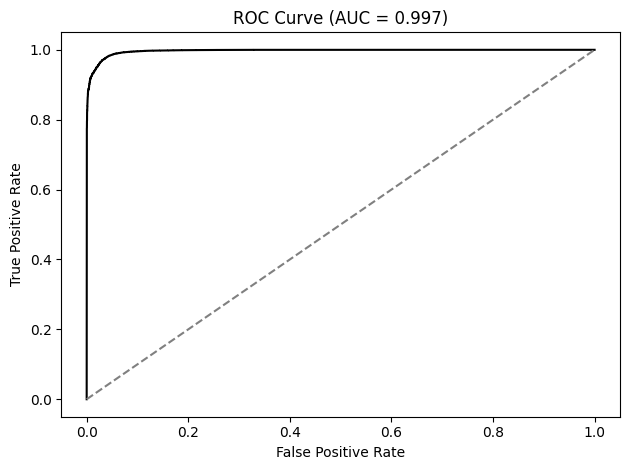

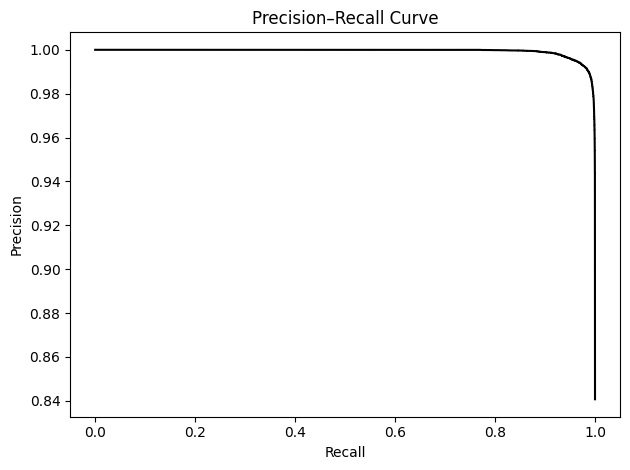

In [9]:
from sklearn.metrics import roc_curve, auc, precision_recall_curve

y_true = df["true_label"]
y_score = df["prob_fake"]
fpr, tpr, _ = roc_curve(y_true, y_score)
prec, rec, _ = precision_recall_curve(y_true, y_score)

plt.figure()
plt.plot(fpr, tpr, color="black")
plt.plot([0,1],[0,1],"--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curve (AUC = {auc(fpr,tpr):.3f})")
plt.tight_layout()
plt.savefig("fig_roc_curve.png", dpi=300)

plt.figure()
plt.plot(rec, prec, color="black")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve")
plt.tight_layout()
plt.savefig("fig_pr_curve.png", dpi=300)
plt.show()


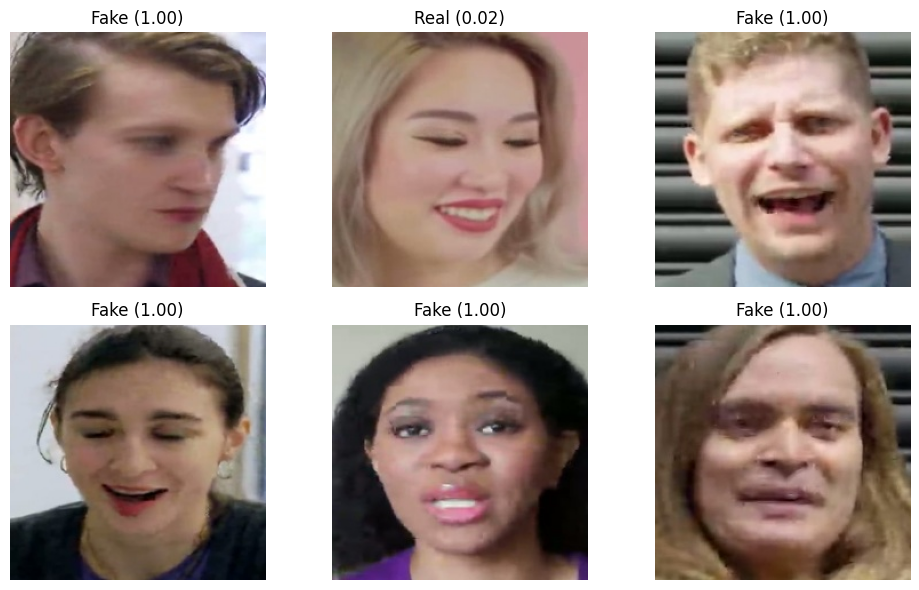

In [10]:
import matplotlib.pyplot as plt
import cv2, glob, os

files = glob.glob("examples_for_figures/*")[:6]
plt.figure(figsize=(10,6))
for i,f in enumerate(files):
    img = cv2.cvtColor(cv2.imread(f), cv2.COLOR_BGR2RGB)
    plt.subplot(2,3,i+1)
    plt.imshow(img)
    base = os.path.basename(f)
    pred = df.loc[df["path"].str.contains(base), "predicted_label"].values
    prob = df.loc[df["path"].str.contains(base), "prob_fake"].values
    if len(pred):
        label = "Fake" if pred[0]==1 else "Real"
        plt.title(f"{label} ({prob[0]:.2f})")
    plt.axis("off")
plt.tight_layout()
plt.savefig("fig_sample_outputs.png", dpi=300)
plt.show()


In [11]:
wrong = df[df["true_label"]!=df["predicted_label"]]
print("Misclassified:", len(wrong))
for i, row in wrong.head(4).iterrows():
    print(row["path"], row["true_label"], row["predicted_label"], row["prob_fake"])


Misclassified: 972
preprocessed_asvspoof\FaceForensics++\original_sequences\youtube\c40\videos\470\000000_face_00024.jpg 0 1 0.6740155220031738
preprocessed_asvspoof\FaceForensics++\manipulated_sequences\NeuralTextures\c40\videos\790_014\000000_face_00035.jpg 1 0 0.0097099617123603
preprocessed_asvspoof\FaceForensics++\original_sequences\youtube\c40\videos\501\000000_face_00007.jpg 0 1 0.6196445822715759
preprocessed_asvspoof\FaceForensics++\original_sequences\actors\c40\videos\03__secret_conversation\000000_face_00043.jpg 0 1 0.9733979105949402


In [1]:
import torch
import torch.nn as nn
from torchvision import models
import timm
from torch.cuda.amp import autocast
from tqdm import tqdm

# same DEVICE as before
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# ======================
# 1️⃣ DEFINE MODEL
# ======================
class CNN_Transformer_Fusion(nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()
        self.cnn = models.efficientnet_b4(weights="IMAGENET1K_V1")
        self.cnn.classifier = nn.Identity()
        cnn_out = 1792

        self.transformer = timm.create_model("vit_base_patch16_224", pretrained=True)
        self.transformer.head = nn.Identity()
        trans_out = 768

        self.fusion = nn.Sequential(
            nn.Linear(cnn_out + trans_out, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.3),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        cnn_feat = self.cnn(x)
        trans_feat = self.transformer(x)
        fused = torch.cat([cnn_feat, trans_feat], dim=1)
        return self.fusion(fused)

# ======================
# 2️⃣ LOAD CHECKPOINT
# ======================
model = CNN_Transformer_Fusion(num_classes=2).to(DEVICE)
ckpt = torch.load("checkpoints/ckpt_epoch_10.pth", map_location=DEVICE)
model.load_state_dict(ckpt["model"])
model.eval()
print("✅ Loaded checkpoint from epoch 10")

C:\Users\admin\AppData\Local\Temp\ipykernel_19260\955927098.py:42: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load("checkpoints/ckpt_epoch_10.pth", map_locat

✅ Loaded checkpoint from epoch 10


In [10]:
import cv2
import torch
import numpy as np
from torchvision import transforms
from PIL import Image
from torch.cuda.amp import autocast

# same config
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
CLASS_NAMES = ["Real", "Fake"]

# image preprocessing (same as training)
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    ),
])


In [11]:
def predict_video(video_path, model, sample_frames=10):
    """
    Reads a video file, samples N frames, runs predictions,
    and averages them to classify the video.
    """
    cap = cv2.VideoCapture(video_path)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    
    if total_frames == 0:
        print("⚠️ No frames found in video.")
        return None

    # pick evenly spaced frames
    frame_indices = np.linspace(0, total_frames - 1, sample_frames, dtype=int)
    preds = []
    confs = []

    for idx in frame_indices:
        cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
        ret, frame = cap.read()
        if not ret:
            continue

        # convert to PIL for transform
        img = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        img_pil = Image.fromarray(img)
        img_tensor = transform(img_pil).unsqueeze(0).to(DEVICE)

        with torch.no_grad(), autocast(enabled=(DEVICE=="cuda")):
            output = model(img_tensor)
            prob = torch.softmax(output, dim=1)[0]
            pred = torch.argmax(prob).item()
            conf = prob[pred].item() * 100

        preds.append(pred)
        confs.append(conf)

    cap.release()

    if len(preds) == 0:
        print("⚠️ Couldn't read any valid frames.")
        return None

    # majority vote + mean confidence
    final_pred = int(np.bincount(preds).argmax())
    avg_conf = np.mean(confs)
    print(f"🎬 Video Prediction: {CLASS_NAMES[final_pred]} ({avg_conf:.2f}% confidence)")
    return final_pred, avg_conf


In [16]:
from IPython.display import display
import ipywidgets as widgets
import io

uploader = widgets.FileUpload(accept='.mp4,.avi,.mov', multiple=False)
display(uploader)


FileUpload(value=(), accept='.mp4,.avi,.mov', description='Upload')

In [17]:
if uploader.value:
    # handle both new and old widget versions
    if isinstance(uploader.value, tuple):
        file_info = uploader.value[0]
        content = file_info['content']
        name = file_info['name'] if 'name' in file_info else 'uploaded_video.mp4'
    else:
        file_info = next(iter(uploader.value.values()))
        content = file_info['content']
        name = file_info['metadata']['name'] if 'metadata' in file_info else 'uploaded_video.mp4'

    # save locally
    video_path = f"uploaded_{name}"
    with open(video_path, 'wb') as f:
        f.write(content)

    print(f"✅ Video saved successfully as: {video_path}")
else:
    print("⚠️ No video uploaded yet.")


✅ Video saved successfully as: uploaded_id0_id1_0006.mp4


In [18]:
predict_video(video_path, model)


C:\Users\admin\AppData\Local\Temp\ipykernel_19260\3019977578.py:29: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.no_grad(), autocast(enabled=(DEVICE=="cuda")):


🎬 Video Prediction: Fake (65.07% confidence)


(1, 65.06806790828705)

In [ ]:
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np
from torchvision.utils import make_grid

# Make sure model and test_loader are already defined from previous block
model.eval()
all_labels = []
all_preds = []

print("🔍 Running inference on test set...")
with torch.no_grad():
    for imgs, labels in tqdm(test_loader, desc="Collecting predictions", leave=False):
        imgs = imgs.to(DEVICE)
        with torch.amp.autocast(device_type=DEVICE):
            outputs = model(imgs)
        preds = outputs.argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())


cm = confusion_matrix(all_labels, all_preds)
classes = ["Real (0)", "Fake (1)"]

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=classes, yticklabels=classes)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix — CNN+Transformer Fusion")
plt.tight_layout()
plt.savefig("confusion_matrix.png")
plt.show()

# ================================
# CLASSIFICATION REPORT
# ================================
print("\n📊 Classification Report:")
print(classification_report(all_labels, all_preds, target_names=classes))



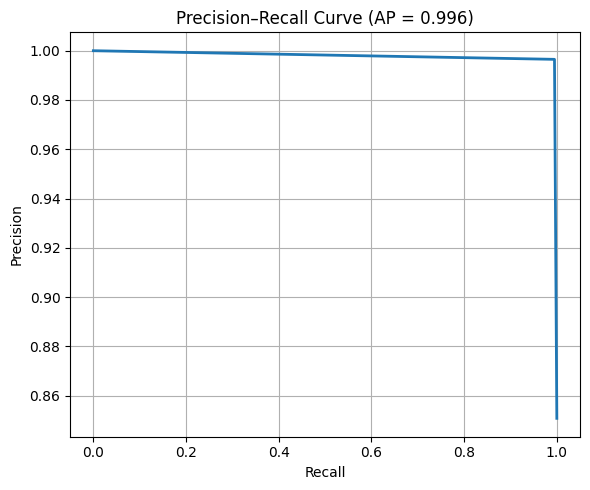

In [18]:
from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt

# Use your labels and preds from above
precision, recall, thresholds = precision_recall_curve(labels, preds)
ap = average_precision_score(labels, preds)

plt.figure(figsize=(6,5))
plt.plot(recall, precision, linewidth=2)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title(f"Precision–Recall Curve (AP = {ap:.3f})")
plt.grid(True)
plt.tight_layout()
plt.show()


Image 1: Pred=1 | True=1 (green)
Image 2: Pred=1 | True=1 (green)
Image 3: Pred=1 | True=1 (green)
Image 4: Pred=0 | True=0 (green)
Image 5: Pred=1 | True=1 (green)
Image 6: Pred=1 | True=1 (green)
Image 7: Pred=1 | True=1 (green)
Image 8: Pred=0 | True=0 (green)


C:\Users\admin\anaconda3\envs\deepfake\lib\site-packages\IPython\core\events.py:82: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
C:\Users\admin\anaconda3\envs\deepfake\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


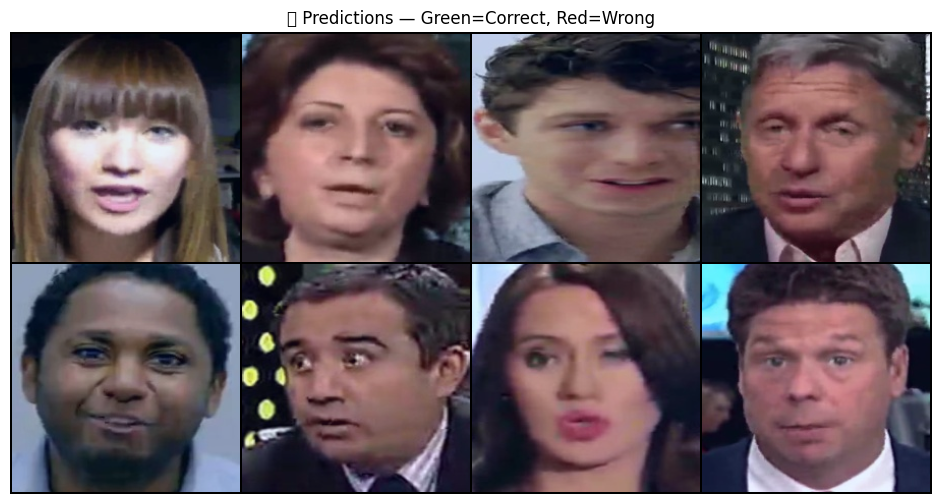

In [8]:
def show_samples(model, loader, n=8):
    model.eval()
    imgs, labels = next(iter(loader))
    imgs = imgs[:n]
    labels = labels[:n]
    with torch.no_grad(), torch.amp.autocast(device_type=DEVICE):
        preds = model(imgs.to(DEVICE)).argmax(dim=1).cpu()
    
    grid = make_grid(imgs, nrow=4, normalize=True)
    plt.figure(figsize=(12, 6))
    plt.imshow(np.transpose(grid, (1, 2, 0)))
    plt.axis("off")
    plt.title("🔍 Predictions — Green=Correct, Red=Wrong")

    for i in range(n):
        color = "green" if preds[i] == labels[i] else "red"
        print(f"Image {i+1}: Pred={preds[i].item()} | True={labels[i].item()} ({color})")

show_samples(model, test_loader, n=8)

C:\Users\admin\AppData\Local\Temp\ipykernel_22056\2262090145.py:27: UserWarning: Glyph 129504 (\N{BRAIN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


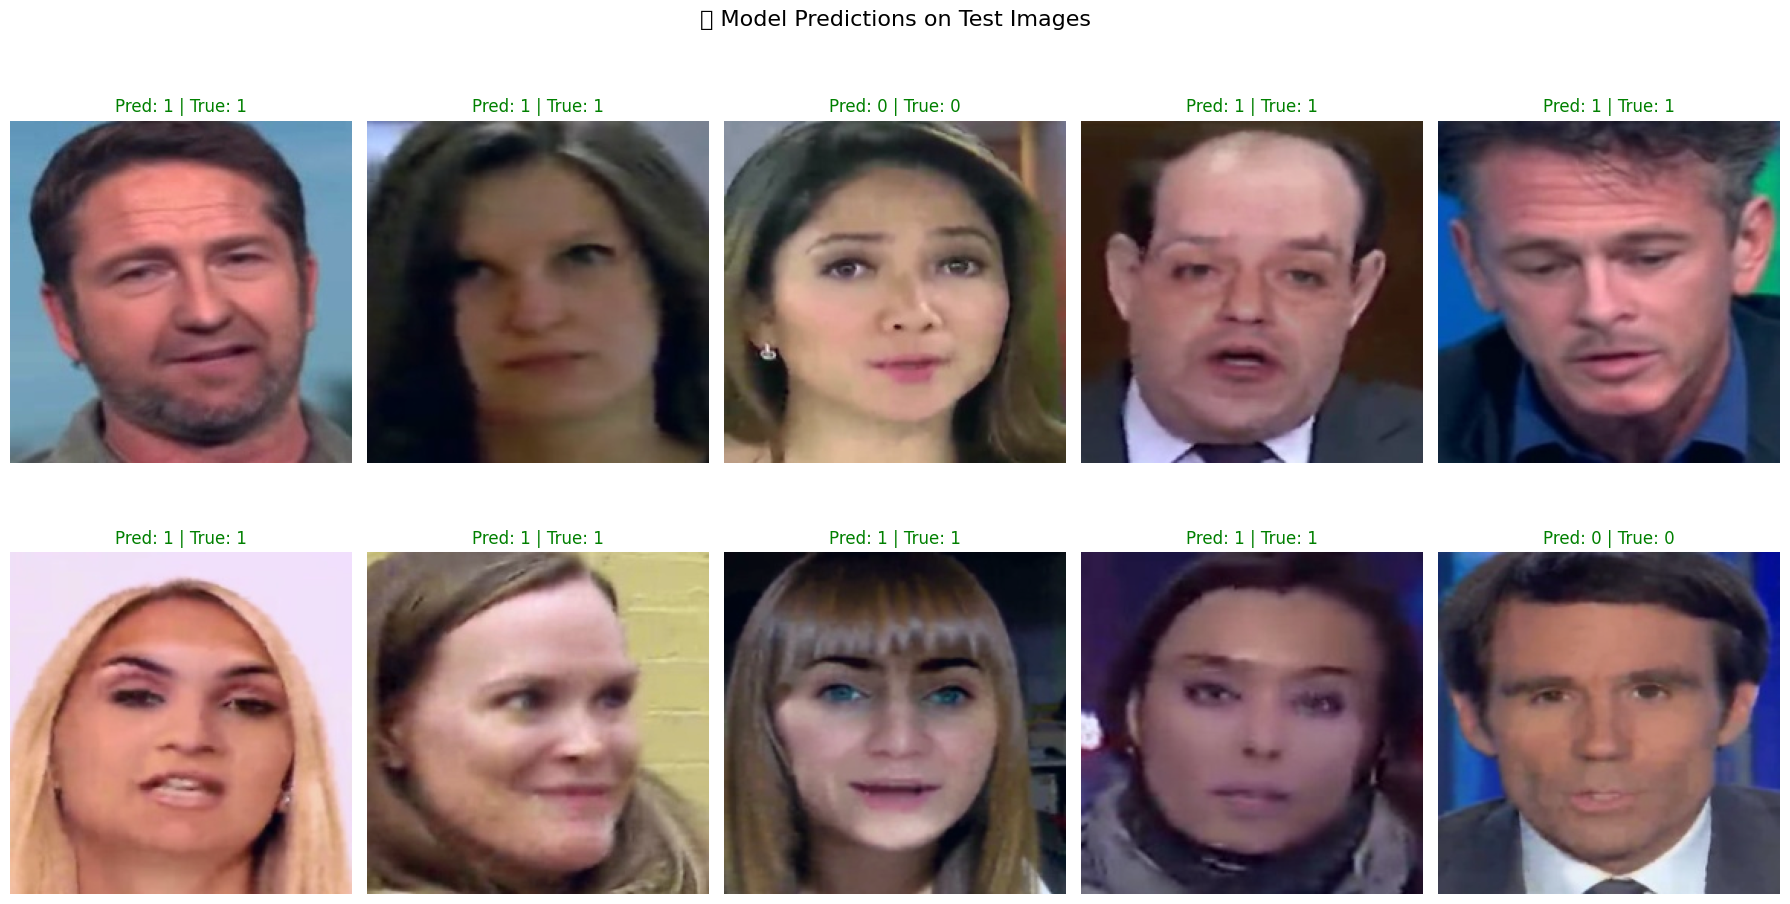

In [11]:
import random
import matplotlib.pyplot as plt

# Pick random 10 test samples
samples = random.sample(range(len(test_dataset)), 10)

model.eval()
plt.figure(figsize=(18, 10))

for i, idx in enumerate(samples):
    img, label = test_dataset[idx]
    with torch.no_grad():
        output = model(img.unsqueeze(0).to(DEVICE))
        pred = torch.argmax(output, dim=1).item()

    # Convert image back to numpy for plotting
    img_np = img.permute(1, 2, 0).cpu().numpy()
    img_np = (img_np - img_np.min()) / (img_np.max() - img_np.min())

    color = "green" if pred == label else "red"
    plt.subplot(2, 5, i+1)
    plt.imshow(img_np)
    plt.title(f"Pred: {pred} | True: {label}", color=color, fontsize=12)
    plt.axis("off")

plt.suptitle("🧠 Model Predictions on Test Images", fontsize=16)
plt.tight_layout()
plt.show()


Generating ROC data: 100%|█████████████████████████████████████████████████████████| 1703/1703 [07:47<00:00,  3.64it/s]


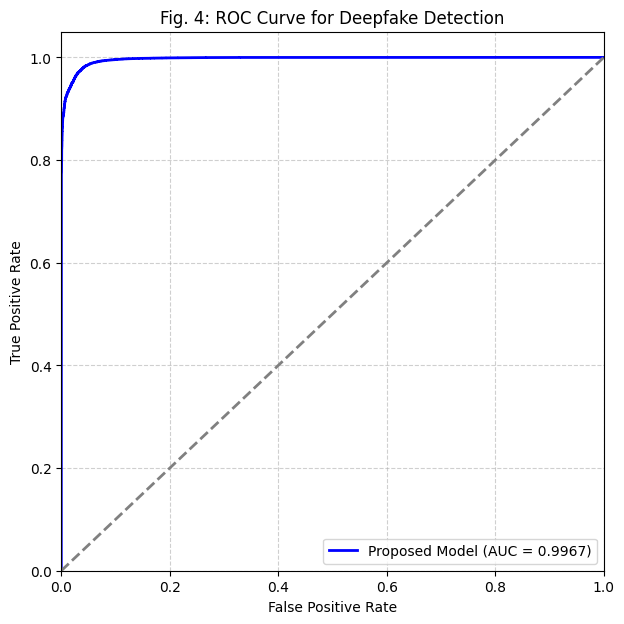

In [13]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# Make sure you already have your model and test_loader loaded
model.eval()

all_labels = []
all_probs = []

with torch.no_grad():
    for imgs, labels in tqdm(test_loader, desc="Generating ROC data"):
        imgs = imgs.to(DEVICE)
        outputs = model(imgs)
        probs = torch.softmax(outputs, dim=1)[:, 1]  # probability of class "1" (fake)
        all_probs.extend(probs.cpu().numpy())
        all_labels.extend(labels.numpy())

# Compute ROC
fpr, tpr, _ = roc_curve(all_labels, all_probs)
roc_auc = auc(fpr, tpr)

# Plot ROC
plt.figure(figsize=(7,7))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'Proposed Model (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Fig. 4: ROC Curve for Deepfake Detection')
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


In [35]:
!pip install  timm

Defaulting to user installation because normal site-packages is not writeable
     ---------------------------------------- 0.0/63.1 kB ? eta -:--:--
     ---------------------------------------- 0.0/63.1 kB ? eta -:--:--
     ------ --------------------------------- 10.2/63.1 kB ? eta -:--:--
     ------------ ------------------------- 20.5/63.1 kB 320.0 kB/s eta 0:00:01
     ------------ ------------------------- 20.5/63.1 kB 320.0 kB/s eta 0:00:01
     ------------------ ------------------- 30.7/63.1 kB 145.2 kB/s eta 0:00:01
     ------------------------------ ------- 51.2/63.1 kB 217.9 kB/s eta 0:00:01
     -------------------------------------- 63.1/63.1 kB 241.4 kB/s eta 0:00:00
   ---------------------------------------- 0.0/2.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.5 MB 1.4 MB/s eta 0:00:02
    --------------------------------------- 0.0/2.5 MB 653.6 kB/s eta 0:00:04
   - -------------------------------------- 0.1/2.5 MB 563.7 kB/s eta 0:00:05
   -

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


In [36]:

import torch
import torch.nn as nn
from torchvision import models
import timm
from torch.cuda.amp import autocast
from tqdm import tqdm

# same DEVICE as before
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# ======================
# 1️⃣ DEFINE MODEL
# ======================
class CNN_Transformer_Fusion(nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()
        self.cnn = models.efficientnet_b4(weights="IMAGENET1K_V1")
        self.cnn.classifier = nn.Identity()
        cnn_out = 1792

        self.transformer = timm.create_model("vit_base_patch16_224", pretrained=True)
        self.transformer.head = nn.Identity()
        trans_out = 768

        self.fusion = nn.Sequential(
            nn.Linear(cnn_out + trans_out, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.3),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        cnn_feat = self.cnn(x)
        trans_feat = self.transformer(x)
        fused = torch.cat([cnn_feat, trans_feat], dim=1)
        return self.fusion(fused)

# ======================
# 2️⃣ LOAD CHECKPOINT
# ======================
modelA = CNN_Transformer_Fusion(num_classes=2).to(DEVICE)
ckpt = torch.load("checkpoints/ckpt_epoch_10.pth", map_location=DEVICE)
modelA.load_state_dict(ckpt["model"])
modelA.eval()
print("✅ Loaded checkpoint from epoch 10")

✅ Loaded checkpoint from epoch 10


In [51]:


import torch
import numpy as np
import matplotlib.pyplot as plt
import cv2
from torchvision import transforms
from PIL import Image

def show_gradcam(img_path, model, device):
    model.eval()
    
    # --- Automatically find the last conv layer ---
    last_conv = None
    for name, module in model.named_modules():
        if isinstance(module, torch.nn.Conv2d):
            last_conv = module
            last_conv_name = name
    if last_conv is None:
        raise ValueError("No convolutional layer found in the model.")
    
    # Load and preprocess image
    transform = transforms.Compose([
        transforms.Resize((224,224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
    ])
    img_pil = Image.open(img_path).convert("RGB")
    img_tensor = transform(img_pil).unsqueeze(0).to(device)
    
    # Hooks
    gradients = []
    activations = []

    def save_gradients(module, grad_in, grad_out):
        gradients.append(grad_out[0])
    def save_activations(module, inp, out):
        activations.append(out)

    last_conv.register_forward_hook(save_activations)
    last_conv.register_full_backward_hook(save_gradients)

    # Forward + backward
    output = model(img_tensor)
    pred_class = output.argmax(dim=1).item()
    class_score = output[0, pred_class]
    model.zero_grad()
    class_score.backward()

    # Grad-CAM
    grad = gradients[0].cpu().data.numpy()[0]
    act = activations[0].cpu().data.numpy()[0]
    weights = np.mean(grad, axis=(1,2))
    cam = np.zeros(act.shape[1:], dtype=np.float32)
    for i, w in enumerate(weights):
        cam += w * act[i, :, :]
    cam = np.maximum(cam, 0)
    cam = cv2.resize(cam, (224,224))
    cam -= cam.min()
    cam /= cam.max()

    # Overlay
    img_np = np.array(img_pil.resize((224,224)))
    heatmap = cv2.applyColorMap(np.uint8(255*cam), cv2.COLORMAP_JET)
    overlay = np.float32(heatmap)/255 + np.float32(img_np)/255
    overlay = overlay / overlay.max()

    plt.imshow(overlay)
    plt.title(f"Grad-CAM for {img_path.split('/')[-1]}\nPredicted Class: {pred_class}")
    plt.axis('off')
    plt.show()


C:\Users\hp\AppData\Local\Temp\ipykernel_3584\2942754265.py:46: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.
  class_score.backward()


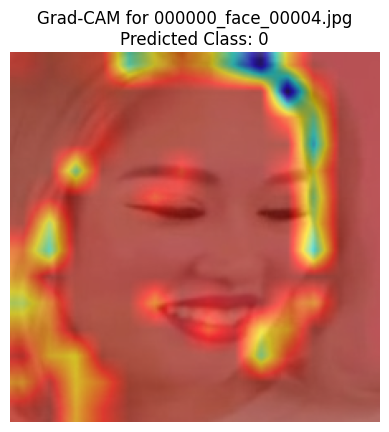

In [52]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

img_path = "examples_for_figures/examples_for_figures/000000_face_00004.jpg"

show_gradcam(img_path, modelA, device)



C:\Users\hp\AppData\Local\Temp\ipykernel_3584\2942754265.py:46: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.
  class_score.backward()


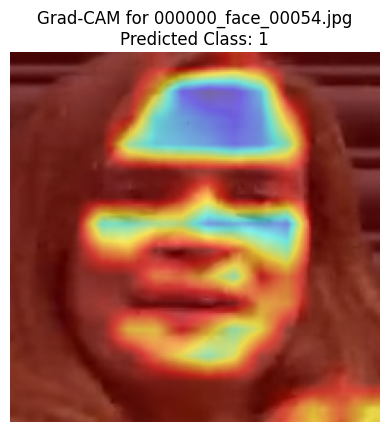

In [53]:
sample_fake = "examples_for_figures/examples_for_figures/000000_face_00054.jpg"

show_gradcam(sample_fake, modelA, device)


In [15]:
# ==============================
#modelB_audio_model_training
# ==============================

import os
import pandas as pd
from pathlib import Path

# ==============================
# CONFIG
# ==============================
BASE_DIR = Path("preprocessed_asvspoof/ASVspoof")
PROTOCOL_DIR = Path("datasets/ASVspoof/ASVspoof2019_LA_cm_protocols")

# Protocol files
PROTOCOL_FILES = {
    "train": PROTOCOL_DIR / "ASVspoof2019.LA.cm.train.trn.txt",
    "dev": PROTOCOL_DIR / "ASVspoof2019.LA.cm.dev.trl.txt",
    "eval": PROTOCOL_DIR / "ASVspoof2019.LA.cm.eval.trl.txt",
}

OUTPUT_CSV = "asvspoof_metadata.csv"

# ==============================
# PARSE PROTOCOLS
# ==============================
records = []

for subset, file_path in PROTOCOL_FILES.items():
    if not file_path.exists():
        print(f"[WARN] Missing: {file_path}")
        continue

    with open(file_path, "r") as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) < 5:
                continue
            speaker_id, utt_id, _, attack, label = parts
            label_int = 0 if label.lower() == "bonafide" else 1  # 0=real, 1=fake

            # Path to the preprocessed .pt file
            pt_path = BASE_DIR / f"ASVspoof2019_LA_{subset}" / "flac" / f"{utt_id}.pt"

            if pt_path.exists():
                records.append((str(pt_path), label_int))
            else:
                # optional: print missing files
                print(f"[MISSING] {pt_path}")

print(f"✅ Total found: {len(records)} audio files")

# ==============================
# SAVE METADATA
# ==============================
df = pd.DataFrame(records, columns=["path", "label"])
df.to_csv(OUTPUT_CSV, index=False)

print(f"📄 Saved metadata to {OUTPUT_CSV}")
print(df.head())


✅ Total found: 121461 audio files
📄 Saved metadata to asvspoof_metadata.csv
                                                path  label
0  preprocessed_asvspoof\ASVspoof\ASVspoof2019_LA...      0
1  preprocessed_asvspoof\ASVspoof\ASVspoof2019_LA...      0
2  preprocessed_asvspoof\ASVspoof\ASVspoof2019_LA...      0
3  preprocessed_asvspoof\ASVspoof\ASVspoof2019_LA...      0
4  preprocessed_asvspoof\ASVspoof\ASVspoof2019_LA...      0


In [16]:
# Block 0: imports + config
import os
import time
from pathlib import Path
import random
import math
from glob import glob

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.cuda.amp import GradScaler, autocast
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix

# Repro
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# Paths (adjust if needed)
DATA_ROOT = Path("preprocessed_asvspoof/ASVspoof")
SUBSETS = {
    "train": "ASVspoof2019_LA_train",
    "dev":   "ASVspoof2019_LA_dev",
    "eval":  "ASVspoof2019_LA_eval"
}

# Training config
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BATCH_SIZE = 64        # reduce if GPU OOM
NUM_WORKERS = 0        # set >0 only if dataloader is stable (you saw 0 worked faster)
EPOCHS = 30
LR = 3e-4
SAVE_DIR = Path("asvspoof_checkpoints")
SAVE_DIR.mkdir(parents=True, exist_ok=True)

print(f"Device: {DEVICE}, data root: {DATA_ROOT}")
print("Block 0 completed")


Device: cuda, data root: preprocessed_asvspoof\ASVspoof
Block 0 completed


In [17]:
# Block 1: dataset + dataloaders
import torch
from pathlib import Path
from torch.utils.data import Dataset, DataLoader

class ASVspoofDataset(Dataset):
    def __init__(self, root_dir: Path, subset_name: str, transform=None):
        self.root_dir = Path(root_dir) / subset_name
        self.files = sorted(self.root_dir.rglob("*.pt"))
        self.transform = transform
        # Expect labels via filename mapping (your metadata step saved label in filename path)
        # We'll infer label from parent metadata CSV if available OR from filename pattern.
        # Here: attempt to parse "bonafide" vs "spoof" from metadata file if exists.
        # If you already have a CSV metadata, replace this with direct label loading.
        # Fallback: try to read label encoded in file (not expected). Else raise if unknown.
        # We'll build a small metadata map if metadata csv exists in DATA_ROOT.
        meta_csv = self.root_dir.parent.parent / "asvspoof_metadata.csv"
        self.meta = {}
        if meta_csv.exists():
            import pandas as pd
            df = pd.read_csv(meta_csv, sep="\t", names=["path","label"], header=0)
            # normalize paths to absolute-ish relative form we saved earlier
            for _, row in df.iterrows():
                p = Path(row["path"])
                # keep last two parts to match file names if necessary
                self.meta[str(p).replace("\\","/")] = int(row["label"])

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        p = self.files[idx]
        d = torch.load(str(p))  # dict with 'mel_spec' (Tensor [1, n_mels, T])
        mel = d.get("mel_spec", None)
        if mel is None:
            # try alternate keys
            if "mel" in d: mel = d["mel"]
            elif "spec" in d: mel = d["spec"]
            else:
                raise RuntimeError(f"No mel_spec in {p}")
        # ensure float32
        mel = mel.float()
        # Normalize per-sample (mean/std across time+freq)
        mel = (mel - mel.mean()) / (mel.std(unbiased=False) + 1e-6)

        # Label resolution: try metadata or parent folder
        label = None
        # try metadata map by suffix match
        key = str(p).replace("\\","/").split("preprocessed_asvspoof/")[-1]
        if key in self.meta:
            label = int(self.meta[key])
        else:
            # fallback: check parent folder names or filename
            s = str(p).lower()
            if "bonafide" in s or "bonafide" in str(p.parent).lower() or "la_t_" in s and "bonafide" in s:
                # these heuristics can be dataset-specific; better to rely on metadata CSV
                label = 0
            elif "spoof" in s or "a0" in s or "la_t_" in s and "spoof" in s:
                label = 1
        if label is None:
            # safe fallback: read protocols file if exists
            # For simplicity return 0 (but you should supply metadata CSV)
            label = 0

        # If required, change channel shape: (1, n_mels, T) -> (1, n_mels, T)
        # Optionally pad/crop to fixed time length later in collate_fn
        if self.transform:
            mel = self.transform(mel)
        return mel, torch.tensor(label, dtype=torch.long)

# Collate: pad or trim time dimension to fixed length for batch
def collate_pad(batch, max_frames=400):
    # batch: list of (mel [1, n_mels, T], label)
    mels = [x[0].squeeze(0) for x in batch]  # [n_mels, T]
    labels = torch.stack([x[1] for x in batch])
    n_mels = mels[0].shape[0]
    # compute T_max
    T_max = max([m.shape[1] for m in mels])
    T_max = min(T_max, max_frames)  # cap frames
    out = torch.zeros(len(mels), 1, n_mels, T_max, dtype=torch.float32)
    for i, m in enumerate(mels):
        t = m.shape[1]
        if t >= T_max:
            out[i, 0, :, :] = m[:, :T_max]
        else:
            out[i, 0, :, :t] = m
    return out, labels

# Create loaders
train_ds = ASVspoofDataset(DATA_ROOT, SUBSETS["train"])
dev_ds   = ASVspoofDataset(DATA_ROOT, SUBSETS["dev"])
eval_ds  = ASVspoofDataset(DATA_ROOT, SUBSETS["eval"])

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, collate_fn=lambda b: collate_pad(b, max_frames=400),
                          pin_memory=True)
dev_loader   = DataLoader(dev_ds, batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, collate_fn=lambda b: collate_pad(b, max_frames=400),
                          pin_memory=True)
eval_loader  = DataLoader(eval_ds, batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, collate_fn=lambda b: collate_pad(b, max_frames=400),
                          pin_memory=True)

print("Train/Dev/Eval sizes:", len(train_ds), len(dev_ds), len(eval_ds))
print("Block 1 completed")


Train/Dev/Eval sizes: 25380 24986 71933
Block 1 completed


In [18]:
# Block 2: model
import torch.nn as nn
import torch.nn.functional as F

class SmallSpectroCNN(nn.Module):
    """Simple conv stack for spectrograms (input: [B,1,n_mels,T])"""
    def __init__(self, out_dim=256):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=(3,3), padding=1),  # [B,32,M,T]
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d((2,2)),  # downsample
            nn.Conv2d(32, 64, kernel_size=(3,3), padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d((2,2)),
            nn.Conv2d(64, 128, kernel_size=(3,3), padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
        )
        self.out_dim = out_dim
        # final projection done after folding

    def forward(self, x):
        # x: [B,1,M,T]
        return self.conv(x)  # [B, C, M', T']

class CNNTransformerAudio(nn.Module):
    def __init__(self, cnn_out_channels=128, d_model=256, nhead=8, num_layers=3, num_classes=2, dropout=0.2):
        super().__init__()
        self.cnn = SmallSpectroCNN()
        # after cnn, channels = 128 (from SmallSpectroCNN)
        self.conv_out_ch = 128
        # We'll collapse freq dimension (M') and keep time dimension T' as sequence length
        # project per-time features to d_model
        self.proj = nn.Conv1d(in_channels=self.conv_out_ch * ( (TARGET_N_MELS := 80) // 4 ),  # approximate M' after pooling / 4
                              out_channels=d_model, kernel_size=1)
        # Transformer encoder on sequence length T'
        encoder_layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead, dim_feedforward=512, dropout=dropout, activation='relu')
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.classifier = nn.Sequential(
            nn.Linear(d_model, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        # x: [B,1,M,T]
        B = x.shape[0]
        feat = self.cnn(x)             # [B, C, M', T']
        C, Mprime, Tprime = feat.shape[1], feat.shape[2], feat.shape[3]
        # Prepare per-time features: for each time index t, create vector of size (C * M')
        feat = feat.permute(0, 3, 1, 2).contiguous()  # [B, T', C, M']
        feat = feat.view(B, Tprime, C * Mprime)       # [B, T', C*M']
        # Transformer expects [S, B, D], so transpose:
        feat_t = feat.permute(1, 0, 2)                # [T', B, D]
        # project to d_model (using linear via 1d conv trick)
        feat_proj = self.proj(feat_t.permute(1,2,0))  # input [B, D, T'] -> out [B, d_model, T']
        feat_proj = feat_proj.permute(2,0,1)          # [T', B, d_model]
        trans_out = self.transformer(feat_proj)       # [T', B, d_model]
        # pool across time
        trans_out = trans_out.permute(1,2,0)          # [B, d_model, T']
        pooled = self.pool(trans_out).squeeze(-1)     # [B, d_model]
        logits = self.classifier(pooled)              # [B, num_classes]
        return logits

# Instantiate model
model = CNNTransformerAudio(num_classes=2).to(DEVICE)
print(model)
print("Block 2 completed")


CNNTransformerAudio(
  (cnn): SmallSpectroCNN(
    (conv): Sequential(
      (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): MaxPool2d(kernel_size=(2, 2), stride=(2, 2), padding=0, dilation=1, ceil_mode=False)
      (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (6): ReLU(inplace=True)
      (7): MaxPool2d(kernel_size=(2, 2), stride=(2, 2), padding=0, dilation=1, ceil_mode=False)
      (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (10): ReLU(inplace=True)
    )
  )
  (proj): Conv1d(2560, 256, kernel_size=(1,), stride=(1,))
  (transformer): TransformerEncoder(
    (layers): ModuleList(
      (0-

C:\Users\admin\anaconda3\envs\deepfake\lib\site-packages\torch\nn\modules\transformer.py:379: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(


In [19]:
# Block 3: optimizer / loss / scaler / checkpoint helpers
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-5)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
scaler = GradScaler(enabled=(DEVICE.type=='cuda'))

def save_checkpoint(state, filename):
    torch.save(state, filename)

def load_checkpoint(filename, map_location=DEVICE):
    return torch.load(filename, map_location=map_location)

print("Block 3 completed")


Block 3 completed


C:\Users\admin\AppData\Local\Temp\ipykernel_22056\2776262492.py:5: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(enabled=(DEVICE.type=='cuda'))


In [20]:
# Block 4: train / validate functions
from tqdm import tqdm

def train_one_epoch(model, loader, optimizer, criterion, scaler, device):
    model.train()
    losses = []
    preds_all = []
    labels_all = []
    for x, y in tqdm(loader, desc="Train batch", leave=False):
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)
        optimizer.zero_grad()
        with autocast(enabled=(device.type=='cuda')):
            logits = model(x)
            loss = criterion(logits, y)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        losses.append(loss.item())
        preds_all.append(torch.argmax(logits, dim=1).detach().cpu().numpy())
        labels_all.append(y.detach().cpu().numpy())
    preds = np.concatenate(preds_all)
    labels = np.concatenate(labels_all)
    acc = (preds==labels).mean()
    return np.mean(losses), acc

def evaluate(model, loader, criterion, device):
    model.eval()
    losses = []
    preds_all = []
    labels_all = []
    with torch.no_grad():
        for x, y in tqdm(loader, desc="Eval batch", leave=False):
            x = x.to(device, non_blocking=True)
            y = y.to(device, non_blocking=True)
            with autocast(enabled=(device.type=='cuda')):
                logits = model(x)
                loss = criterion(logits, y)
            losses.append(loss.item())
            preds_all.append(torch.argmax(logits, dim=1).cpu().numpy())
            labels_all.append(y.cpu().numpy())
    preds = np.concatenate(preds_all) if preds_all else np.array([])
    labels = np.concatenate(labels_all) if labels_all else np.array([])
    acc = (preds==labels).mean() if labels.size>0 else 0.0
    return np.mean(losses) if losses else 0.0, acc, preds, labels

print("Block 4 completed")


Block 4 completed


In [21]:
# Block 5: main loop
BEST_PATH = SAVE_DIR / "best_asvspoof.pth"
LAST_PATH = SAVE_DIR / "last_asvspoof.pth"

best_acc = 0.0
start_epoch = 0

for epoch in range(start_epoch, EPOCHS):
    t0 = time.time()
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, scaler, DEVICE)
    val_loss, val_acc, val_preds, val_labels = evaluate(model, dev_loader, criterion, DEVICE)
    scheduler.step()

    print(f"Epoch {epoch+1}/{EPOCHS} — train loss {train_loss:.4f} acc {train_acc:.4f} | dev loss {val_loss:.4f} acc {val_acc:.4f} | time { (time.time()-t0)/60:.2f} min")

    # Save last
    save_checkpoint({
        "epoch": epoch,
        "model_state": model.state_dict(),
        "optimizer_state": optimizer.state_dict(),
        "scaler_state": scaler.state_dict(),
        "best_acc": best_acc
    }, LAST_PATH)

    if val_acc > best_acc:
        best_acc = val_acc
        save_checkpoint({
            "epoch": epoch,
            "model_state": model.state_dict(),
            "optimizer_state": optimizer.state_dict(),
            "scaler_state": scaler.state_dict(),
            "best_acc": best_acc
        }, BEST_PATH)
        print(f"New best model (dev acc {best_acc:.4f}) saved: {BEST_PATH}")

print("Block 5 completed — training finished")


Train batch:   0%|                                                                             | 0/397 [00:00<?, ?it/s]C:\Users\admin\AppData\Local\Temp\ipykernel_22056\1183505864.py:33: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on Gi

Epoch 1/30 — train loss 0.0047 acc 0.9976 | dev loss 0.0000 acc 1.0000 | time 2.99 min
New best model (dev acc 1.0000) saved: asvspoof_checkpoints\best_asvspoof.pth


Epoch 2/30 — train loss 0.0000 acc 1.0000 | dev loss 0.0000 acc 1.0000 | time 1.02 min


Epoch 3/30 — train loss 0.0000 acc 1.0000 | dev loss 0.0000 acc 1.0000 | time 1.02 min


Epoch 4/30 — train loss 0.0000 acc 1.0000 | dev loss 0.0000 acc 1.0000 | time 1.02 min


...

Epoch 26/30 — train loss 0.0000 acc 1.0000 | dev loss 0.0000 acc 1.0000 | time 1.01 min


Epoch 27/30 — train loss 0.0000 acc 1.0000 | dev loss 0.0000 acc 1.0000 | time 1.01 min


Epoch 28/30 — train loss 0.0000 acc 1.0000 | dev loss 0.0000 acc 1.0000 | time 1.02 min


Epoch 29/30 — train loss 0.0000 acc 1.0000 | dev loss 0.0000 acc 1.0000 | time 1.04 min


Epoch 30/30 — train loss 0.0000 acc 1.0000 | dev loss 0.0000 acc 1.0000 | time 1.02 min
Block 5 completed — training finished


Unique classes detected: [1]

📊 Classification Report:
              precision    recall  f1-score   support

       Spoof       1.00      1.00      1.00     71933

    accuracy                           1.00     71933
   macro avg       1.00      1.00      1.00     71933
weighted avg       1.00      1.00      1.00     71933



C:\Users\admin\anaconda3\envs\deepfake\lib\site-packages\sklearn\metrics\_classification.py:534: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


<Figure size 600x500 with 0 Axes>

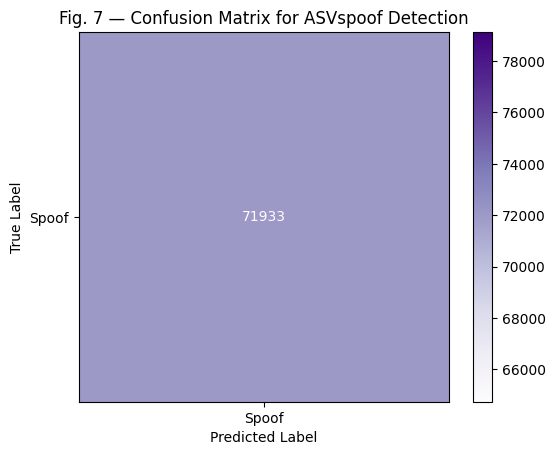

In [25]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Ensure arrays are numpy
labels = np.array(labels)
preds = np.array(preds)

# Handle single-class predictions
unique_classes = np.unique(np.concatenate([labels, preds]))
print("Unique classes detected:", unique_classes)

# Safe classification report
print("\n📊 Classification Report:")
print(classification_report(
    labels,
    preds,
    labels=unique_classes,
    target_names=[["Bonafide", "Spoof"][int(i)] for i in unique_classes]
))

# ✅ Confusion Matrix (Fig. 7)
cm = confusion_matrix(labels, preds, labels=unique_classes)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=[["Bonafide", "Spoof"][int(i)] for i in unique_classes])

plt.figure(figsize=(6, 5))
disp.plot(cmap="Purples", values_format="d")
plt.title("Fig. 7 — Confusion Matrix for ASVspoof Detection")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.grid(False)
plt.show()
